# Logical $T$-gate CSB learning and PEC

In [1]:
from importlib import reload
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import logical_csb as t
reload(t)

# Shared execution settings
N_JOBS = 20
BASE_SEED = 1234

MIN_EC_ROUNDS = 2
MAX_EC_ROUNDS = 4
DECODER_CACHE = Path("steane_flag_decoder_stabilizer_max4.pkl")

CIRCUIT_OPTIONS = {
    "prep_gates_noisy": True,
    "prep_qec_after_gate": True,
    "measurement_basis_gates_noisy": True,
    "qec_after_each_logical_gate": True,
    "fallback_on_unverified": True,
}

TWO_QUBIT_FACTOR = 2.0
FINAL_MEAS_FACTOR = 1.0
PHASE_TWIRL = True


SAVE_FIGURES = True
FIGURE_DIR = Path(".")

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

MAGIC_NU_ISOTROPIC = {"X": 1/3, "Y": 1/3, "Z": 1/3}

decoder = t.get_or_build_decoder(
    cache_file=DECODER_CACHE,
    min_rounds=MIN_EC_ROUNDS,
    max_rounds=MAX_EC_ROUNDS,
    verbose=False,
)


## Shared sweep and plotting helpers

In [2]:
def run_repeated_t_sweep(
    schedule,
    parameter_name,
    model_factory,
    *,
    steps,
    shots,
    chunk_shots,
    n_repeats,
    seed_offset,
):
    """Run independent complete T-CSB workflows and keep all results in memory."""
    rows = []

    for point_id, point in enumerate(schedule):
        rep = int(point["rep"])
        parameter_value = float(point[parameter_name])
        model = model_factory(point)

        for repeat_id in range(int(n_repeats)):
            seed = int(
                BASE_SEED
                + seed_offset
                + point_id * 1_000_003
                + repeat_id * 10_000_019
            )
            csb_df = t.run_t_csb_spectrum(
                decoder=decoder,
                model=model,
                options=CIRCUIT_OPTIONS,
                steps=steps,
                rep=rep,
                shots=shots,
                seed=seed,
                n_jobs=N_JOBS,
                chunk_shots=chunk_shots,
                cache_file=DECODER_CACHE,
                min_rounds=MIN_EC_ROUNDS,
                max_rounds=MAX_EC_ROUNDS,
                verbose=False,
            )
            fit = t.fit_t_csb_spectra(csb_df)["summary_df"].iloc[0].to_dict()
            fit.update({
                parameter_name: parameter_value,
                "rep": rep,
                "repeat_id": repeat_id,
                "seed": seed,
            })
            rows.append(fit)

    raw = pd.DataFrame(rows)
    raw["loss_g"] = 1.0 - raw["g"]
    raw["loss_f"] = 1.0 - raw["f"]
    raw["abs_loss_f"] = np.abs(raw["loss_f"])
    raw["abs_delta_theta"] = np.abs(raw["delta_theta"])

    value_columns = [
        "g", "f", "loss_g", "loss_f", "abs_loss_f",
        "delta_theta", "abs_delta_theta", "process_infidelity",
        "p_I", "p_X", "p_Y", "p_Z", "gamma_per_cycle",
    ]
    aggregation = {}
    for column in value_columns:
        aggregation[f"{column}_mean"] = (column, "mean")
        aggregation[f"{column}_std"] = (column, "std")

    summary = (
        raw.groupby([parameter_name, "rep"], as_index=False)
        .agg(n_repeats=("repeat_id", "nunique"), **aggregation)
        .sort_values(parameter_name)
        .reset_index(drop=True)
    )
    for column in summary.columns:
        if column.endswith("_std"):
            summary[column] = summary[column].fillna(0.0)
    return raw, summary


def positive_log_error(y, error):
    y = np.asarray(y, dtype=float)
    error = np.asarray(error, dtype=float)
    error = np.where(np.isfinite(error), error, 0.0)
    return np.vstack([np.minimum(error, 0.95 * y), error])


def fixed_power_amplitude(x, y, power, yerr=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    basis = x[mask] ** power
    values = y[mask]
    if yerr is None:
        return float(np.dot(basis, values) / np.dot(basis, basis))
    errors = np.asarray(yerr, dtype=float)[mask]
    good = np.isfinite(errors) & (errors > 0)
    if np.all(good):
        weights = 1.0 / errors**2
        return float(np.sum(weights * basis * values) / np.sum(weights * basis**2))
    return float(np.dot(basis, values) / np.dot(basis, basis))


def format_axis(ax):
    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)


def save_pdf(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches="tight")

## 1. Operational gadget faults

The accepted magic state is ideal and the common circuit-level stochastic Pauli strength is varied. For a distance-three fault-tolerant gadget, the leading logical spectral loss is expected to be quadratic in the weak-noise regime.

In [3]:
GADGET_REP_SCHEDULE = [
    {"p_gadget": 1.0e-5, "rep": 10001},
    {"p_gadget": 3.0e-5, "rep": 1001},
    {"p_gadget": 1.0e-4, "rep": 97},
    {"p_gadget": 3.0e-4, "rep": 9},
    {"p_gadget": 1.0e-3, "rep": 1},
]
GADGET_CSB_STEPS = list(range(13))
GADGET_CSB_SHOTS = 1000
GADGET_CSB_CHUNK_SHOTS = 100
GADGET_N_REPEATS = 10


def gadget_model(point):
    return t.make_t_noise_model(
        gadget_strength=float(point["p_gadget"]),
        two_qubit_factor=TWO_QUBIT_FACTOR,
        final_meas_factor=FINAL_MEAS_FACTOR,
        magic_angle_error=0.0,
        magic_error_rate=0.0,
        magic_nu=MAGIC_NU_ISOTROPIC,
        phase_twirl=PHASE_TWIRL,
    )


gadget_repeats_df, gadget_summary_df = run_repeated_t_sweep(
    GADGET_REP_SCHEDULE,
    "p_gadget",
    gadget_model,
    steps=GADGET_CSB_STEPS,
    shots=GADGET_CSB_SHOTS,
    chunk_shots=GADGET_CSB_CHUNK_SHOTS,
    n_repeats=GADGET_N_REPEATS,
    seed_offset=10_000,
)

# Non-unital translation t: mean ± std over complete-workflow repeats
t_summary_df = (
    gadget_repeats_df
    .groupby(["p_gadget", "rep"], as_index=False)
    .agg(
        t_mean=("t", "mean"),
        t_std=("t", "std"),
    )
)

# Merge into the existing summary table
gadget_summary_df = (
    gadget_summary_df
    .drop(columns=["t_mean", "t_std"], errors="ignore")
    .merge(
        t_summary_df,
        on=["p_gadget", "rep"],
        how="left",
    )
)

display(gadget_summary_df[[
    "p_gadget", "rep",
    "loss_g_mean", "loss_g_std",
    "loss_f_mean", "loss_f_std",
    "delta_theta_mean", "delta_theta_std",
    "process_infidelity_mean", "process_infidelity_std",
    "t_mean", "t_std",
]])

,p_gadget,rep,loss_g_mean,loss_g_std,loss_f_mean,loss_f_std,delta_theta_mean,delta_theta_std,process_infidelity_mean,process_infidelity_std,t_mean,t_std
0,0.00001,10001,0.000018,7.620811e-07,0.000013,6.463372e-07,-1.858810e-07,7.625538e-07,0.000012,4.846544e-07,-7.661954e-08,2.101290e-07
1,0.00003,1001,0.000161,6.690367e-06,0.000120,3.337345e-06,-7.131965e-07,1.023340e-05,0.000110,3.564072e-06,-2.561138e-07,1.271572e-06
2,0.00010,97,0.001779,5.181297e-05,0.001293,4.593523e-05,-2.199548e-05,8.008895e-05,0.001213,2.988713e-05,8.376782e-06,1.780548e-05
3,0.00030,9,0.014769,6.504809e-04,0.010469,5.470601e-04,-4.263029e-04,9.429879e-04,0.010002,3.033593e-04,-1.081506e-04,1.453513e-04
4,0.00100,1,0.126027,7.138159e-03,0.092411,1.449124e-03,2.044938e-03,6.865698e-03,0.086126,3.640867e-03,1.806419e-03,1.861600e-03


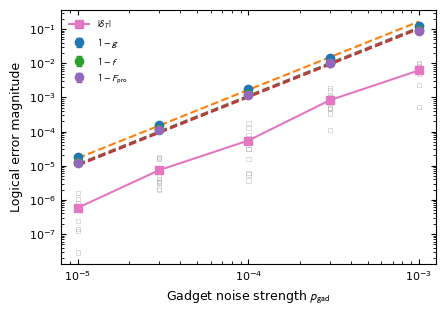

In [4]:
x = gadget_summary_df["p_gadget"].to_numpy(float)
fit_grid = np.geomspace(x.min(), x.max(), 300)

quantities = [
    (r"$1-g$", "loss_g_mean", "loss_g_std"),
    (r"$1-f$", "loss_f_mean", "loss_f_std"),
    (r"$1-F_{\rm pro}$", "process_infidelity_mean", "process_infidelity_std"),
]

with mpl.rc_context({
    "font.family": "sans-serif",
    "mathtext.fontset": "stixsans",
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
}):
    fig, ax = plt.subplots(figsize=(4.5, 3.2))

    # --------------------------------------------------------
    # Attenuation and process-infidelity scaling
    # --------------------------------------------------------
    for label, mean_col, std_col in quantities:
        y = gadget_summary_df[mean_col].to_numpy(float)
        yerr = gadget_summary_df[std_col].to_numpy(float)

        keep = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x > 0)
            & (y > 0)
        )

        amplitude = fixed_power_amplitude(
            x,
            y,
            2,
            yerr,
        )

        ax.errorbar(
            x[keep],
            y[keep],
            yerr=positive_log_error(
                y[keep],
                yerr[keep],
            ),
            marker="o",
            linestyle="none",
            capsize=2,
            label=label,
        )

        ax.plot(
            fit_grid,
            amplitude * fit_grid**2,
            "--",
        )

    # --------------------------------------------------------
    # Coherent phase error: individual repeats + mean
    # --------------------------------------------------------
    raw_x = gadget_repeats_df[
        "p_gadget"
    ].to_numpy(float)

    raw_delta = gadget_repeats_df[
        "abs_delta_theta"
    ].to_numpy(float)

    raw_keep = (
        np.isfinite(raw_x)
        & np.isfinite(raw_delta)
        & (raw_x > 0)
        & (raw_delta > 0)
    )

    # Independent complete-workflow estimates
    ax.scatter(
        raw_x[raw_keep],
        raw_delta[raw_keep],
        s=10,
        marker="s",
        facecolors="none",
        edgecolors="0.70",
        linewidths=0.5,
        alpha=0.65,
        zorder=1,
    )

    # Mean absolute phase error
    delta_mean = gadget_summary_df[
        "abs_delta_theta_mean"
    ].to_numpy(float)

    keep = (
        np.isfinite(x)
        & np.isfinite(delta_mean)
        & (x > 0)
        & (delta_mean > 0)
    )

    ax.plot(
        x[keep],
        delta_mean[keep],
        marker="s",
        linestyle="-",
        label=r"$|\delta_T|$",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Gadget noise strength $p_{\rm gad}$"
    )
    ax.set_ylabel(
        "Logical error magnitude"
    )

    format_axis(ax)

    ax.legend(
        frameon=False,
    )

    fig.tight_layout()

    # save_pdf(fig, "fig_t_gadget_fault_scaling.pdf")

    plt.show()

## 2. Systematic accepted-state angle error

With an ideal consuming circuit, the accepted resource-state angle error gives $g=\cos\epsilon_A$ and $1-F_{\rm pro}=(1-g)/2$.

In [5]:
ANGLE_REP_SCHEDULE = [
    {"epsilon_A": 0.005, "rep": 4801},
    {"epsilon_A": 0.01, "rep": 1201},
    {"epsilon_A": 0.02, "rep": 401},
    {"epsilon_A": 0.04, "rep": 97},
    {"epsilon_A": 0.08, "rep": 25},
]
ANGLE_CSB_STEPS = list(range(13))
ANGLE_CSB_SHOTS = 1000
ANGLE_CSB_CHUNK_SHOTS = 100
ANGLE_N_REPEATS = 10


def angle_model(point):
    return t.ideal_t_noise_model(
        magic_angle_error=float(point["epsilon_A"]),
        magic_error_rate=0.0,
        magic_nu=MAGIC_NU_ISOTROPIC,
        phase_twirl=PHASE_TWIRL,
    )


angle_repeats_df, angle_summary_df = run_repeated_t_sweep(
    ANGLE_REP_SCHEDULE,
    "epsilon_A",
    angle_model,
    steps=ANGLE_CSB_STEPS,
    shots=ANGLE_CSB_SHOTS,
    chunk_shots=ANGLE_CSB_CHUNK_SHOTS,
    n_repeats=ANGLE_N_REPEATS,
    seed_offset=20_000,
)

angle_summary_df["analytic_loss_g"] = 1.0 - np.cos(angle_summary_df["epsilon_A"])
angle_summary_df["analytic_process_infidelity"] = 0.5 * angle_summary_df["analytic_loss_g"]

t_angle_summary_df = (
    angle_repeats_df
    .groupby(
        ["epsilon_A", "rep"],
        as_index=False,
    )
    .agg(
        t_mean=("t", "mean"),
        t_std=("t", "std"),
    )
)

angle_summary_df = (
    angle_summary_df
    .drop(
        columns=["t_mean", "t_std"],
        errors="ignore",
    )
    .merge(
        t_angle_summary_df,
        on=["epsilon_A", "rep"],
        how="left",
    )
)


display(angle_summary_df[[
    "epsilon_A", "rep",

    "loss_g_mean", "loss_g_std",

    "delta_theta_mean", "delta_theta_std",

    "process_infidelity_mean", "process_infidelity_std",

    "t_mean", "t_std",
]])

,epsilon_A,rep,loss_g_mean,loss_g_std,delta_theta_mean,delta_theta_std,process_infidelity_mean,process_infidelity_std,t_mean,t_std
0,0.005,4801,0.000013,2.848295e-07,1.191064e-07,5.400245e-07,0.000006,1.424147e-07,0.0,0.0
1,0.010,1201,0.000050,4.724602e-06,-4.600508e-07,3.656982e-06,0.000025,2.362301e-06,0.0,0.0
2,0.020,401,0.000197,6.248803e-06,3.473866e-06,9.494210e-06,0.000098,3.124411e-06,0.0,0.0
3,0.040,97,0.000799,3.931774e-05,-2.725519e-05,4.521348e-05,0.000399,1.965859e-05,0.0,0.0
4,0.080,25,0.003185,1.139138e-04,-4.839564e-05,1.375160e-04,0.001593,5.696016e-05,0.0,0.0


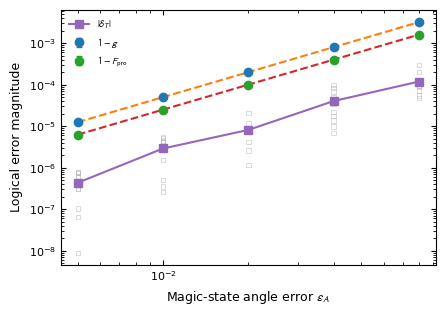

In [6]:
x = angle_summary_df["epsilon_A"].to_numpy(float)
x_grid = np.geomspace(x.min(), x.max(), 300)

with mpl.rc_context({
    "font.family": "sans-serif",
    "mathtext.fontset": "stixsans",
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
}):
    fig, ax = plt.subplots(figsize=(4.5, 3.2))

    # --------------------------------------------------------
    # Attenuation and process-infidelity scaling
    # --------------------------------------------------------
    for label, mean_col, std_col, analytic in [
        (
            r"$1-g$",
            "loss_g_mean",
            "loss_g_std",
            1.0 - np.cos(x_grid),
        ),
        (
            r"$1-F_{\rm pro}$",
            "process_infidelity_mean",
            "process_infidelity_std",
            0.5 * (1.0 - np.cos(x_grid)),
        ),
    ]:
        y = angle_summary_df[mean_col].to_numpy(float)
        yerr = angle_summary_df[std_col].to_numpy(float)

        keep = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x > 0)
            & (y > 0)
        )

        ax.errorbar(
            x[keep],
            y[keep],
            yerr=positive_log_error(
                y[keep],
                yerr[keep],
            ),
            marker="o",
            linestyle="none",
            capsize=2,
            label=label,
        )

        ax.plot(
            x_grid,
            analytic,
            "--",
        )

    # --------------------------------------------------------
    # Coherent phase error: individual repeats + mean
    # --------------------------------------------------------
    raw_x = angle_repeats_df[
        "epsilon_A"
    ].to_numpy(float)

    raw_delta = angle_repeats_df[
        "abs_delta_theta"
    ].to_numpy(float)

    raw_keep = (
        np.isfinite(raw_x)
        & np.isfinite(raw_delta)
        & (raw_x > 0)
        & (raw_delta > 0)
    )

    # Independent complete-workflow estimates
    ax.scatter(
        raw_x[raw_keep],
        raw_delta[raw_keep],
        s=10,
        marker="s",
        facecolors="none",
        edgecolors="0.70",
        linewidths=0.5,
        alpha=0.65,
        zorder=1,
    )

    # Mean absolute phase error
    delta_mean = angle_summary_df[
        "abs_delta_theta_mean"
    ].to_numpy(float)

    keep = (
        np.isfinite(x)
        & np.isfinite(delta_mean)
        & (x > 0)
        & (delta_mean > 0)
    )

    ax.plot(
        x[keep],
        delta_mean[keep],
        marker="s",
        linestyle="-",
        label=r"$|\delta_T|$",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Magic-state angle error $\epsilon_A$"
    )
    ax.set_ylabel(
        "Logical error magnitude"
    )

    format_axis(ax)

    ax.legend(
        frameon=False,
    )

    fig.tight_layout()

    # save_pdf(fig, "fig_t_magic_angle_scaling.pdf")

    plt.show()

## 3. Stochastic accepted-state errors

For isotropic accepted-state Pauli noise, $\nu_X=\nu_Y=\nu_Z=1/3$, the ideal consuming circuit gives $g=1-4r_A/3$ and $f=1$.

In [7]:
RANDOM_REP_SCHEDULE = [
    {"r_A": 1.0e-4, "rep": 641},
    {"r_A": 5.0e-4, "rep": 121},
    {"r_A": 1.0e-3, "rep": 65},
    {"r_A": 5.0e-3, "rep": 25},
    {"r_A": 1.0e-2, "rep": 9},
]
RANDOM_CSB_STEPS = list(range(13))
RANDOM_CSB_SHOTS = 1000
RANDOM_CSB_CHUNK_SHOTS = 100
RANDOM_N_REPEATS = 10


def random_resource_model(point):
    return t.ideal_t_noise_model(
        magic_angle_error=0.0,
        magic_error_rate=float(point["r_A"]),
        magic_nu=MAGIC_NU_ISOTROPIC,
        phase_twirl=PHASE_TWIRL,
    )


magic_random_repeats_df, magic_random_summary_df = run_repeated_t_sweep(
    RANDOM_REP_SCHEDULE,
    "r_A",
    random_resource_model,
    steps=RANDOM_CSB_STEPS,
    shots=RANDOM_CSB_SHOTS,
    chunk_shots=RANDOM_CSB_CHUNK_SHOTS,
    n_repeats=RANDOM_N_REPEATS,
    seed_offset=30_000,
)

magic_random_summary_df["analytic_loss_g"] = 4.0 * magic_random_summary_df["r_A"] / 3.0
magic_random_summary_df["analytic_process_infidelity"] = 2.0 * magic_random_summary_df["r_A"] / 3.0

t_random_summary_df = (
    magic_random_repeats_df
    .groupby(
        ["r_A", "rep"],
        as_index=False,
    )
    .agg(
        t_mean=("t", "mean"),
        t_std=("t", "std"),
    )
)

magic_random_summary_df = (
    magic_random_summary_df
    .drop(
        columns=["t_mean", "t_std"],
        errors="ignore",
    )
    .merge(
        t_random_summary_df,
        on=["r_A", "rep"],
        how="left",
    )
)


display(magic_random_summary_df[[
    "r_A", "rep",

    "loss_g_mean", "loss_g_std",

    "abs_loss_f_mean", "abs_loss_f_std",

    "delta_theta_mean", "delta_theta_std",

    "process_infidelity_mean", "process_infidelity_std",

    "t_mean", "t_std",
]])

,r_A,rep,loss_g_mean,loss_g_std,abs_loss_f_mean,abs_loss_f_std,delta_theta_mean,delta_theta_std,process_infidelity_mean,process_infidelity_std,t_mean,t_std
0,0.0001,641,0.000132,0.000004,0.0,0.0,0.000004,0.000009,0.000066,0.000002,0.0,0.0
1,0.0005,121,0.000644,0.000035,0.0,0.0,-0.000007,0.000035,0.000322,0.000018,0.0,0.0
2,0.0010,65,0.001311,0.000049,0.0,0.0,-0.000014,0.000076,0.000655,0.000024,0.0,0.0
3,0.0050,25,0.006820,0.000324,0.0,0.0,-0.000228,0.000250,0.003410,0.000162,0.0,0.0
4,0.0100,9,0.013305,0.000569,0.0,0.0,0.000415,0.000826,0.006653,0.000284,0.0,0.0


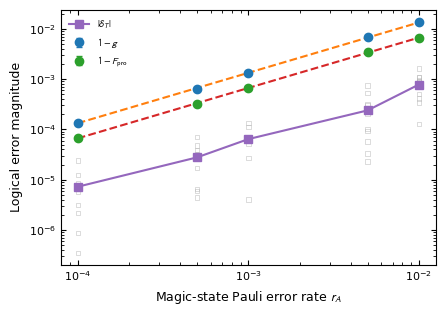

In [8]:
x = magic_random_summary_df["r_A"].to_numpy(float)
x_grid = np.geomspace(x.min(), x.max(), 300)

with mpl.rc_context({
    "font.family": "sans-serif",
    "mathtext.fontset": "stixsans",
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
}):
    fig, ax = plt.subplots(figsize=(4.5, 3.2))

    # Attenuation and process-infidelity scaling
    for label, mean_col, std_col, analytic in [
        (
            r"$1-g$",
            "loss_g_mean",
            "loss_g_std",
            4.0 * x_grid / 3.0,
        ),
        (
            r"$1-F_{\rm pro}$",
            "process_infidelity_mean",
            "process_infidelity_std",
            2.0 * x_grid / 3.0,
        ),
    ]:
        y = magic_random_summary_df[mean_col].to_numpy(float)
        yerr = magic_random_summary_df[std_col].to_numpy(float)

        keep = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x > 0)
            & (y > 0)
        )

        ax.errorbar(
            x[keep],
            y[keep],
            yerr=positive_log_error(
                y[keep],
                yerr[keep],
            ),
            marker="o",
            linestyle="none",
            capsize=2,
            label=label,
        )

        ax.plot(
            x_grid,
            analytic,
            "--",
        )

    # Individual |delta_T| estimates
    raw_x = magic_random_repeats_df[
        "r_A"
    ].to_numpy(float)

    raw_delta = magic_random_repeats_df[
        "abs_delta_theta"
    ].to_numpy(float)

    raw_keep = (
        np.isfinite(raw_x)
        & np.isfinite(raw_delta)
        & (raw_x > 0)
        & (raw_delta > 0)
    )

    ax.scatter(
        raw_x[raw_keep],
        raw_delta[raw_keep],
        s=10,
        marker="s",
        facecolors="none",
        edgecolors="0.70",
        linewidths=0.5,
        alpha=0.65,
        zorder=1,
    )

    # Mean |delta_T|
    delta_mean = magic_random_summary_df[
        "abs_delta_theta_mean"
    ].to_numpy(float)

    keep = (
        np.isfinite(x)
        & np.isfinite(delta_mean)
        & (x > 0)
        & (delta_mean > 0)
    )

    ax.plot(
        x[keep],
        delta_mean[keep],
        marker="s",
        linestyle="-",
        label=r"$|\delta_T|$",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Magic-state Pauli error rate $r_A$"
    )
    ax.set_ylabel(
        "Logical error magnitude"
    )

    format_axis(ax)
    ax.legend(frameon=False)

    fig.tight_layout()

    # save_pdf(fig, "fig_t_magic_pauli_scaling.pdf")

    plt.show()

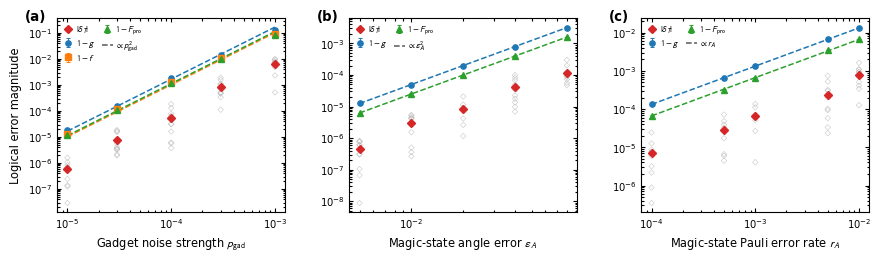

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D


# ============================================================
# Helpers
# ============================================================

def positive_log_error(mean, std):
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)
    std = np.where(np.isfinite(std), std, 0.0)

    lower = np.minimum(std, 0.95 * mean)
    return np.vstack([lower, std])


def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        length=3.0,
        width=0.8,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        length=1.8,
    )


def panel_label(ax, text):
    ax.text(
        -0.14,
        1.045,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="top",
    )


def fixed_power_amplitude(x, y, power, yerr=None):
    """
    Constrained weighted fit:
        y = A x^power
    Only A is fitted.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    keep = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
    )

    x_fit = x[keep]
    y_fit = y[keep]
    basis = x_fit**power

    if yerr is None:
        weights = np.ones_like(y_fit)
    else:
        err = np.asarray(yerr, dtype=float)[keep]
        weights = np.ones_like(y_fit)

        valid = (
            np.isfinite(err)
            & (err > 0)
        )
        weights[valid] = 1.0 / err[valid]**2

    return float(
        np.sum(weights * basis * y_fit)
        / np.sum(weights * basis**2)
    )


# ============================================================
# Figure
# ============================================================

with mpl.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "mathtext.fontset": "stixsans",
    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 6.2,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.1,
    "lines.markersize": 3.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(8.8, 2.65),
    )

    colors = mpl.rcParams[
        "axes.prop_cycle"
    ].by_key()["color"]


    # ========================================================
    # (a) Gadget noise: quadratic fits
    # ========================================================

    ax = axes[0]

    x = gadget_summary_df[
        "p_gadget"
    ].to_numpy(float)

    x_grid = np.geomspace(
        np.min(x[x > 0]),
        np.max(x),
        400,
    )

    quantities = [
        (
            r"$1-g$",
            "loss_g_mean",
            "loss_g_std",
            0,
            "o",
        ),
        (
            r"$1-f$",
            "loss_f_mean",
            "loss_f_std",
            1,
            "s",
        ),
        (
            r"$1-F_{\rm pro}$",
            "process_infidelity_mean",
            "process_infidelity_std",
            2,
            "^",
        ),
    ]

    for label, mean_col, std_col, color_id, marker in quantities:

        y = gadget_summary_df[
            mean_col
        ].to_numpy(float)

        yerr = gadget_summary_df[
            std_col
        ].to_numpy(float)

        keep = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x > 0)
            & (y > 0)
        )

        amplitude = fixed_power_amplitude(
            x,
            y,
            power=2,
            yerr=yerr,
        )

        ax.errorbar(
            x[keep],
            y[keep],
            yerr=positive_log_error(
                y[keep],
                yerr[keep],
            ),
            marker=marker,
            linestyle="none",
            color=colors[color_id],
            capsize=1.6,
            capthick=0.7,
            elinewidth=0.65,
            label=label,
            zorder=3,
        )

        ax.plot(
            x_grid,
            amplitude * x_grid**2,
            linestyle="--",
            color=colors[color_id],
            zorder=2,
        )

    # Individual |delta_T|
    raw_x = gadget_repeats_df[
        "p_gadget"
    ].to_numpy(float)

    raw_delta = gadget_repeats_df[
        "abs_delta_theta"
    ].to_numpy(float)

    raw_keep = (
        np.isfinite(raw_x)
        & np.isfinite(raw_delta)
        & (raw_x > 0)
        & (raw_delta > 0)
    )

    ax.scatter(
        raw_x[raw_keep],
        raw_delta[raw_keep],
        s=8,
        marker="D",
        facecolors="none",
        edgecolors="0.70",
        linewidths=0.45,
        alpha=0.65,
        zorder=1,
    )

    delta_mean = gadget_summary_df[
        "abs_delta_theta_mean"
    ].to_numpy(float)

    keep = (
        np.isfinite(x)
        & np.isfinite(delta_mean)
        & (x > 0)
        & (delta_mean > 0)
    )

    ax.plot(
        x[keep],
        delta_mean[keep],
        marker="D",
        linestyle="none",
        color=colors[3],
        label=r"$|\delta_T|$",
        zorder=4,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(
        r"Gadget noise strength $p_{\rm gad}$"
    )
    ax.set_ylabel(
        "Logical error magnitude"
    )

    handles, labels = ax.get_legend_handles_labels()
    handles.append(
        Line2D(
            [0], [0],
            linestyle="--",
            color="0.35",
            linewidth=1.1,
        )
    )
    labels.append(
        r"$\propto p_{\rm gad}^2$"
    )

    ax.legend(
        handles,
        labels,
        loc="upper left",
        frameon=False,
        ncol=2,
        columnspacing=0.70,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.25,
        labelspacing=0.30,
    )

    format_axis(ax)
    panel_label(ax, "(a)")


    # ========================================================
    # (b) Magic-state angle error: quadratic fits
    # ========================================================

    ax = axes[1]

    x = angle_summary_df[
        "epsilon_A"
    ].to_numpy(float)

    x_grid = np.geomspace(
        np.min(x[x > 0]),
        np.max(x),
        400,
    )

    quantities = [
        (
            r"$1-g$",
            "loss_g_mean",
            "loss_g_std",
            0,
            "o",
        ),
        (
            r"$1-F_{\rm pro}$",
            "process_infidelity_mean",
            "process_infidelity_std",
            2,
            "^",
        ),
    ]

    for label, mean_col, std_col, color_id, marker in quantities:

        y = angle_summary_df[
            mean_col
        ].to_numpy(float)

        yerr = angle_summary_df[
            std_col
        ].to_numpy(float)

        keep = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x > 0)
            & (y > 0)
        )

        amplitude = fixed_power_amplitude(
            x,
            y,
            power=2,
            yerr=yerr,
        )

        ax.errorbar(
            x[keep],
            y[keep],
            yerr=positive_log_error(
                y[keep],
                yerr[keep],
            ),
            marker=marker,
            linestyle="none",
            color=colors[color_id],
            capsize=1.6,
            capthick=0.7,
            elinewidth=0.65,
            label=label,
            zorder=3,
        )

        ax.plot(
            x_grid,
            amplitude * x_grid**2,
            linestyle="--",
            color=colors[color_id],
            zorder=2,
        )

    # Individual |delta_T|
    raw_x = angle_repeats_df[
        "epsilon_A"
    ].to_numpy(float)

    raw_delta = angle_repeats_df[
        "abs_delta_theta"
    ].to_numpy(float)

    raw_keep = (
        np.isfinite(raw_x)
        & np.isfinite(raw_delta)
        & (raw_x > 0)
        & (raw_delta > 0)
    )

    ax.scatter(
        raw_x[raw_keep],
        raw_delta[raw_keep],
        s=8,
        marker="D",
        facecolors="none",
        edgecolors="0.70",
        linewidths=0.45,
        alpha=0.65,
        zorder=1,
    )

    delta_mean = angle_summary_df[
        "abs_delta_theta_mean"
    ].to_numpy(float)

    keep = (
        np.isfinite(x)
        & np.isfinite(delta_mean)
        & (x > 0)
        & (delta_mean > 0)
    )

    ax.plot(
        x[keep],
        delta_mean[keep],
        marker="D",
        linestyle="none",
        color=colors[3],
        label=r"$|\delta_T|$",
        zorder=4,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(
        r"Magic-state angle error $\epsilon_A$"
    )

    handles, labels = ax.get_legend_handles_labels()
    handles.append(
        Line2D(
            [0], [0],
            linestyle="--",
            color="0.35",
            linewidth=1.1,
        )
    )
    labels.append(
        r"$\propto \epsilon_A^2$"
    )

    ax.legend(
        handles,
        labels,
        loc="upper left",
        frameon=False,
        ncol=2,
        columnspacing=0.70,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.25,
        labelspacing=0.30,
    )

    format_axis(ax)
    panel_label(ax, "(b)")


    # ========================================================
    # (c) Magic-state Pauli error: linear fits
    # ========================================================

    ax = axes[2]

    x = magic_random_summary_df[
        "r_A"
    ].to_numpy(float)

    x_grid = np.geomspace(
        np.min(x[x > 0]),
        np.max(x),
        400,
    )

    quantities = [
        (
            r"$1-g$",
            "loss_g_mean",
            "loss_g_std",
            0,
            "o",
        ),
        (
            r"$1-F_{\rm pro}$",
            "process_infidelity_mean",
            "process_infidelity_std",
            2,
            "^",
        ),
    ]

    for label, mean_col, std_col, color_id, marker in quantities:

        y = magic_random_summary_df[
            mean_col
        ].to_numpy(float)

        yerr = magic_random_summary_df[
            std_col
        ].to_numpy(float)

        keep = (
            np.isfinite(x)
            & np.isfinite(y)
            & (x > 0)
            & (y > 0)
        )

        amplitude = fixed_power_amplitude(
            x,
            y,
            power=1,
            yerr=yerr,
        )

        ax.errorbar(
            x[keep],
            y[keep],
            yerr=positive_log_error(
                y[keep],
                yerr[keep],
            ),
            marker=marker,
            linestyle="none",
            color=colors[color_id],
            capsize=1.6,
            capthick=0.7,
            elinewidth=0.65,
            label=label,
            zorder=3,
        )

        ax.plot(
            x_grid,
            amplitude * x_grid,
            linestyle="--",
            color=colors[color_id],
            zorder=2,
        )

    # Individual |delta_T|
    raw_x = magic_random_repeats_df[
        "r_A"
    ].to_numpy(float)

    raw_delta = magic_random_repeats_df[
        "abs_delta_theta"
    ].to_numpy(float)

    raw_keep = (
        np.isfinite(raw_x)
        & np.isfinite(raw_delta)
        & (raw_x > 0)
        & (raw_delta > 0)
    )

    ax.scatter(
        raw_x[raw_keep],
        raw_delta[raw_keep],
        s=8,
        marker="D",
        facecolors="none",
        edgecolors="0.70",
        linewidths=0.45,
        alpha=0.65,
        zorder=1,
    )

    delta_mean = magic_random_summary_df[
        "abs_delta_theta_mean"
    ].to_numpy(float)

    keep = (
        np.isfinite(x)
        & np.isfinite(delta_mean)
        & (x > 0)
        & (delta_mean > 0)
    )

    ax.plot(
        x[keep],
        delta_mean[keep],
        marker="D",
        linestyle="none",
        color=colors[3],
        label=r"$|\delta_T|$",
        zorder=4,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(
        r"Magic-state Pauli error rate $r_A$"
    )

    handles, labels = ax.get_legend_handles_labels()
    handles.append(
        Line2D(
            [0], [0],
            linestyle="--",
            color="0.35",
            linewidth=1.1,
        )
    )
    labels.append(
        r"$\propto r_A$"
    )

    ax.legend(
        handles,
        labels,
        loc="upper left",
        frameon=False,
        ncol=2,
        columnspacing=0.70,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.25,
        labelspacing=0.30,
    )

    format_axis(ax)
    panel_label(ax, "(c)")


    # ========================================================
    # Layout
    # ========================================================

    fig.subplots_adjust(
        left=0.072,
        right=0.995,
        bottom=0.225,
        top=0.955,
        wspace=0.28,
    )

    fig.savefig(
        "t_gate_error_scaling.pdf",
        bbox_inches="tight",
    )

    plt.show()

## 4. Logical $T$-gate learning and random-circuit PEC

The complete workflow learns the phase-twirled logical $T$ channel, independently learns the logical Clifford Pauli channel, and applies both inverse models to random Clifford-plus-$T$ circuits.

In [10]:
COMBINED_GADGET_STRENGTH = 3.0e-4
COMBINED_MAGIC_ANGLE_ERROR = 0.01
COMBINED_MAGIC_ERROR_RATE = 1.0e-4
COMBINED_MAGIC_NU = MAGIC_NU_ISOTROPIC

T_LEARN_STEPS = list(range(13))
T_LEARN_REP = 9
T_LEARN_SHOTS = 1000
T_LEARN_CHUNK_SHOTS = 100

CLIFFORD_LEARN_STEPS = list(range(13))
CLIFFORD_LEARN_REP = 9
CLIFFORD_LEARN_SHOTS = 1000
CLIFFORD_LEARN_CHUNK_SHOTS = 100

PEC_DEPTHS = [ 4, 8, 12, 16, 24]
PEC_SEQUENCES_PER_DEPTH = 20
PEC_NOISY_SHOTS = 10000
PEC_SHOTS = 100000
COMBINED_N_REPEATS = 10

combined_model = t.make_t_noise_model(
    gadget_strength=COMBINED_GADGET_STRENGTH,
    two_qubit_factor=TWO_QUBIT_FACTOR,
    final_meas_factor=FINAL_MEAS_FACTOR,
    magic_angle_error=COMBINED_MAGIC_ANGLE_ERROR,
    magic_error_rate=COMBINED_MAGIC_ERROR_RATE,
    magic_nu=COMBINED_MAGIC_NU,
    phase_twirl=PHASE_TWIRL,
)

In [11]:
t_repeat_rows = []
clifford_repeat_rows = []
pec_repeat_rows = []

for repeat_id in range(COMBINED_N_REPEATS):
    seed = BASE_SEED + 100_000 + repeat_id * 10_000_019

    # T-cycle learning
    t_csb_df = t.run_t_csb_spectrum(
        decoder=decoder,
        model=combined_model,
        options=CIRCUIT_OPTIONS,
        steps=T_LEARN_STEPS,
        rep=T_LEARN_REP,
        shots=T_LEARN_SHOTS,
        seed=seed,
        n_jobs=N_JOBS,
        chunk_shots=T_LEARN_CHUNK_SHOTS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )
    t_learning = t.fit_t_csb_spectra(t_csb_df)
    t_row = t_learning["summary_df"].iloc[0].to_dict()
    t_row["repeat_id"] = repeat_id
    t_repeat_rows.append(t_row)

    # Shared logical-Clifford learning
    clifford_learning = t.learn_clifford_pauli_model(
        decoder=decoder,
        noise=combined_model.gadget_noise,
        options=CIRCUIT_OPTIONS,
        steps=CLIFFORD_LEARN_STEPS,
        rep=CLIFFORD_LEARN_REP,
        shots=CLIFFORD_LEARN_SHOTS,
        chunk_shots=CLIFFORD_LEARN_CHUNK_SHOTS,
        seed=seed + 1_000_003,
        n_jobs=N_JOBS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )
    c_row = clifford_learning["pauli_df"].iloc[0].to_dict()
    c_row["repeat_id"] = repeat_id
    clifford_repeat_rows.append(c_row)

    # Random Clifford+T PEC validation
    validation = t.run_random_circuit_pec_validation(
        decoder=decoder,
        model=combined_model,
        options=CIRCUIT_OPTIONS,
        clifford_inverse_q=clifford_learning["inverse_q"],
        t_inverse_q=t_learning["inverse_q"],
        depths=PEC_DEPTHS,
        sequences_per_depth=PEC_SEQUENCES_PER_DEPTH,
        noisy_shots=PEC_NOISY_SHOTS,
        pec_shots=PEC_SHOTS,
        seed=seed + 2_000_003,
        n_jobs=N_JOBS,
        cache_file=DECODER_CACHE,
        min_rounds=MIN_EC_ROUNDS,
        max_rounds=MAX_EC_ROUNDS,
        verbose=False,
    )
    p = validation["summary_df"].copy()
    p["repeat_id"] = repeat_id
    pec_repeat_rows.append(p)


t_repeats_df = pd.DataFrame(t_repeat_rows)
clifford_repeats_df = pd.DataFrame(clifford_repeat_rows)
pec_repeats_df = pd.concat(pec_repeat_rows, ignore_index=True)


def global_mean_std(df, value_cols):
    row = {}
    for col in value_cols:
        values = df[col].to_numpy(float)
        row[f"{col}_mean"] = float(np.mean(values))
        row[f"{col}_std"] = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    return pd.DataFrame([row])


def grouped_mean_std(df, group_col, value_cols):
    agg = {}
    for col in value_cols:
        agg[f"{col}_mean"] = (col, "mean")
        agg[f"{col}_std"] = (col, "std")
    out = df.groupby(group_col, as_index=False).agg(**agg)
    for col in out.columns:
        if col.endswith("_std"):
            out[col] = out[col].fillna(0.0)
    return out


t_with_abs = t_repeats_df.assign(abs_delta_theta=np.abs(t_repeats_df["delta_theta"]))
T_PAULI_SUMMARY = global_mean_std(
    t_with_abs,
    ["g", "f", "abs_delta_theta", "process_infidelity", "p_I", "p_X", "p_Y", "p_Z", "gamma_per_cycle"],
)

CLIFFORD_PAULI_SUMMARY = global_mean_std(
    clifford_repeats_df,
    ["p_I", "p_X", "p_Y", "p_Z", "gamma_per_cycle"],
)

PEC_SUMMARY = grouped_mean_std(
    pec_repeats_df,
    "depth",
    ["noisy_abs_error_mean", "pec_abs_error_mean", "noisy_probability_mean", "pec_probability_mean"],
).sort_values("depth").reset_index(drop=True)

# Keep output compact: only the learned T channel and PEC summary are shown.
display(T_PAULI_SUMMARY)
display(PEC_SUMMARY)


,g_mean,g_std,f_mean,f_std,abs_delta_theta_mean,abs_delta_theta_std,process_infidelity_mean,process_infidelity_std,p_I_mean,p_I_std,p_X_mean,p_X_std,p_Y_mean,p_Y_std,p_Z_mean,p_Z_std,gamma_per_cycle_mean,gamma_per_cycle_std
0,0.985082,0.000541,0.989401,0.0004,0.000479,0.000327,0.010109,0.000269,0.989891,0.000269,0.00265,0.0001,0.00265,0.0001,0.004809,0.000307,1.020501,0.000554


,depth,noisy_abs_error_mean_mean,noisy_abs_error_mean_std,pec_abs_error_mean_mean,pec_abs_error_mean_std,noisy_probability_mean_mean,noisy_probability_mean_std,pec_probability_mean_mean,pec_probability_mean_std
0,4,0.015199,0.001877,0.001325,0.000235,0.543814,0.043001,0.546907,0.045860
1,8,0.030546,0.004669,0.001703,0.000319,0.488338,0.042489,0.485906,0.048248
2,12,0.050032,0.007203,0.002308,0.000703,0.505089,0.064276,0.506017,0.078611
3,16,0.063295,0.007052,0.002327,0.000416,0.492693,0.049623,0.489990,0.065410
4,24,0.085533,0.011668,0.003593,0.000798,0.506002,0.048194,0.508758,0.073530


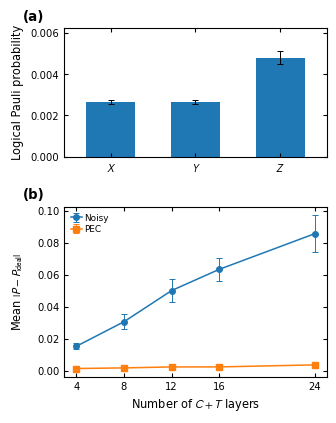

In [12]:
t_row = T_PAULI_SUMMARY.iloc[0]


def panel_label(ax, text):
    ax.text(
        -0.16,
        1.035,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )


with mpl.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "mathtext.fontset": "stixsans",
    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 6.4,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.1,
    "lines.markersize": 4.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}):

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(3.45, 4.10),
        gridspec_kw={
            "height_ratios": [0.76, 1.0],
        },
    )

    # ========================================================
    # (a) Logical T-gate Pauli probabilities
    # ========================================================

    ax = axes[0]

    labels = [
        r"$X$",
        r"$Y$",
        r"$Z$",
    ]

    values = np.array([
        t_row["p_X_mean"],
        t_row["p_Y_mean"],
        t_row["p_Z_mean"],
    ])

    errors = np.array([
        t_row["p_X_std"],
        t_row["p_Y_std"],
        t_row["p_Z_std"],
    ])

    xpos = np.arange(3)

    ax.bar(
        xpos,
        values,
        yerr=errors,
        width=0.58,
        capsize=2.0,
        error_kw={
            "elinewidth": 0.7,
            "capthick": 0.7,
        },
    )

    ax.set_xticks(
        xpos,
        labels,
    )

    ax.set_ylabel(
        "Logical Pauli probability",
        labelpad=5,
    )

    ax.set_ylim(
        0,
        1.22 * np.max(values + errors),
    )

    ax.set_xlim(-0.55, 2.55)

    format_axis(ax)
    panel_label(ax, "(a)")


    # ========================================================
    # (b) Random C+T circuit PEC
    # ========================================================

    ax = axes[1]

    depth = PEC_SUMMARY[
        "depth"
    ].to_numpy(int)

    noisy_mean = PEC_SUMMARY[
        "noisy_abs_error_mean_mean"
    ].to_numpy(float)

    noisy_std = PEC_SUMMARY[
        "noisy_abs_error_mean_std"
    ].to_numpy(float)

    pec_mean = PEC_SUMMARY[
        "pec_abs_error_mean_mean"
    ].to_numpy(float)

    pec_std = PEC_SUMMARY[
        "pec_abs_error_mean_std"
    ].to_numpy(float)

    ax.errorbar(
        depth,
        noisy_mean,
        yerr=noisy_std,
        marker="o",
        linestyle="-",
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.7,
        label="Noisy",
    )

    ax.errorbar(
        depth,
        pec_mean,
        yerr=pec_std,
        marker="s",
        linestyle="-",
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.7,
        label="PEC",
    )

    ax.set_xticks(depth)

    ax.set_xlabel(
        r"Number of $C+T$ layers",
        labelpad=4,
    )

    ax.set_ylabel(
        r"Mean $|P-P_{\rm ideal}|$",
        labelpad=5,
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.30,
        labelspacing=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(b)")


    # ========================================================
    # Layout
    # ========================================================

    # Align the two y-axis labels exactly.
    fig.align_ylabels(axes)

    fig.subplots_adjust(
        left=0.225,
        right=0.985,
        bottom=0.115,
        top=0.965,
        hspace=0.34,
    )

    # fig.savefig(
    #     "t_pauli_learning_pec.pdf",
    #     bbox_inches="tight",
    #     pad_inches=0.03,
    # )

    plt.show()

In [14]:
# ============================================================
# Unified paper figure style
# ============================================================

SINGLE_COLUMN_WIDTH = 3.45

PAPER_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],
    "mathtext.fontset": "stixsans",

    "font.size": 7.2,
    "axes.labelsize": 8.2,
    "axes.titlesize": 8.2,
    "xtick.labelsize": 7.2,
    "ytick.labelsize": 7.2,
    "legend.fontsize": 6.4,

    "axes.linewidth": 0.8,
    "lines.linewidth": 1.1,
    "lines.markersize": 4.0,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}


def format_axis(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        width=0.8,
        length=3.0,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        length=1.8,
    )


def panel_label(ax, text):
    ax.text(
        -0.16,
        1.035,
        text,
        transform=ax.transAxes,
        fontsize=9.5,
        fontweight="bold",
        ha="left",
        va="bottom",
        clip_on=False,
    )

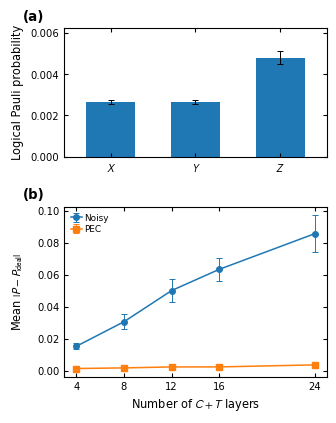

In [15]:
t_row = T_PAULI_SUMMARY.iloc[0]

with mpl.rc_context(PAPER_RC):

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(SINGLE_COLUMN_WIDTH, 4.10),
        gridspec_kw={
            "height_ratios": [0.76, 1.0],
        },
    )

    # ========================================================
    # (a) Logical T-gate Pauli probabilities
    # ========================================================

    ax = axes[0]

    labels = [
        r"$X$",
        r"$Y$",
        r"$Z$",
    ]

    values = np.array([
        t_row["p_X_mean"],
        t_row["p_Y_mean"],
        t_row["p_Z_mean"],
    ])

    errors = np.array([
        t_row["p_X_std"],
        t_row["p_Y_std"],
        t_row["p_Z_std"],
    ])

    xpos = np.arange(3)

    ax.bar(
        xpos,
        values,
        yerr=errors,
        width=0.58,
        capsize=2.0,
        error_kw={
            "elinewidth": 0.7,
            "capthick": 0.7,
        },
    )

    ax.set_xticks(
        xpos,
        labels,
    )

    ax.set_ylabel(
        "Logical Pauli probability",
        labelpad=5,
    )

    ax.set_ylim(
        0,
        1.22 * np.max(values + errors),
    )

    ax.set_xlim(
        -0.55,
        2.55,
    )

    format_axis(ax)
    panel_label(ax, "(a)")


    # ========================================================
    # (b) Random C+T circuit PEC
    # ========================================================

    ax = axes[1]

    depth = PEC_SUMMARY[
        "depth"
    ].to_numpy(int)

    noisy_mean = PEC_SUMMARY[
        "noisy_abs_error_mean_mean"
    ].to_numpy(float)

    noisy_std = PEC_SUMMARY[
        "noisy_abs_error_mean_std"
    ].to_numpy(float)

    pec_mean = PEC_SUMMARY[
        "pec_abs_error_mean_mean"
    ].to_numpy(float)

    pec_std = PEC_SUMMARY[
        "pec_abs_error_mean_std"
    ].to_numpy(float)

    ax.errorbar(
        depth,
        noisy_mean,
        yerr=noisy_std,
        marker="o",
        linestyle="-",
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.7,
        label="Noisy",
    )

    ax.errorbar(
        depth,
        pec_mean,
        yerr=pec_std,
        marker="s",
        linestyle="-",
        capsize=2.0,
        capthick=0.7,
        elinewidth=0.7,
        label="PEC",
    )

    ax.set_xticks(depth)

    ax.set_xlabel(
        r"Number of $C+T$ layers",
        labelpad=4,
    )

    ax.set_ylabel(
        r"Mean $|P-P_{\rm ideal}|$",
        labelpad=5,
    )

    ax.legend(
        loc="upper left",
        frameon=False,
        handlelength=1.25,
        handletextpad=0.30,
        borderaxespad=0.30,
        labelspacing=0.25,
    )

    format_axis(ax)
    panel_label(ax, "(b)")


    # ========================================================
    # Layout
    # ========================================================

    fig.align_ylabels(axes)

    fig.subplots_adjust(
        left=0.225,
        right=0.985,
        bottom=0.115,
        top=0.965,
        hspace=0.34,
    )

    fig.savefig(
        "t_pauli_learning_pec.pdf",
        bbox_inches="tight",
        pad_inches=0.03,
    )

    plt.show()

## 5. Resource-only analytic check

In [ ]:
analytic = t.analytic_resource_only_parameters(
    magic_angle_error=COMBINED_MAGIC_ANGLE_ERROR,
    magic_error_rate=COMBINED_MAGIC_ERROR_RATE,
    magic_nu=COMBINED_MAGIC_NU,
)
pd.Series(analytic)